In [1]:
!nvidia-smi

Sat Mar 28 05:46:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# !pip install roboflow
!pip install -U ultralytics
!pip install ultralytics
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="dqJb8eGc4r2Em1upBUpa")
project = rf.workspace("subhams-workspace-rcrwh").project("indian-emergency-vehicles-reanp")
version = project.version(1)
dataset = version.download("yolo11")
                
                
                
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.9 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of 


Extracting Dataset Version Zip to Indian-emergency-vehicles-1 in yolo11:: 100%|██████████| 42763/42763 [00:04<00:00, 8954.95it/s] 


In [3]:
from ultralytics import YOLO
from IPython.display import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
dataset.location

'/kaggle/working/Indian-emergency-vehicles-1'

In [5]:
from ultralytics import YOLO

# Use the working configuration I created
model = YOLO('yolo11n.pt')

# Train immediately
results = model.train(
    data="/kaggle/working/Indian-emergency-vehicles-1/data.yaml",
    epochs=100,
    batch=32,
    device=[0, 1],
    optimizer='MuSGD',
    # lr0=0.001
)

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Indian-emergency-vehicles-1/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nb

In [6]:
from IPython.display import Image

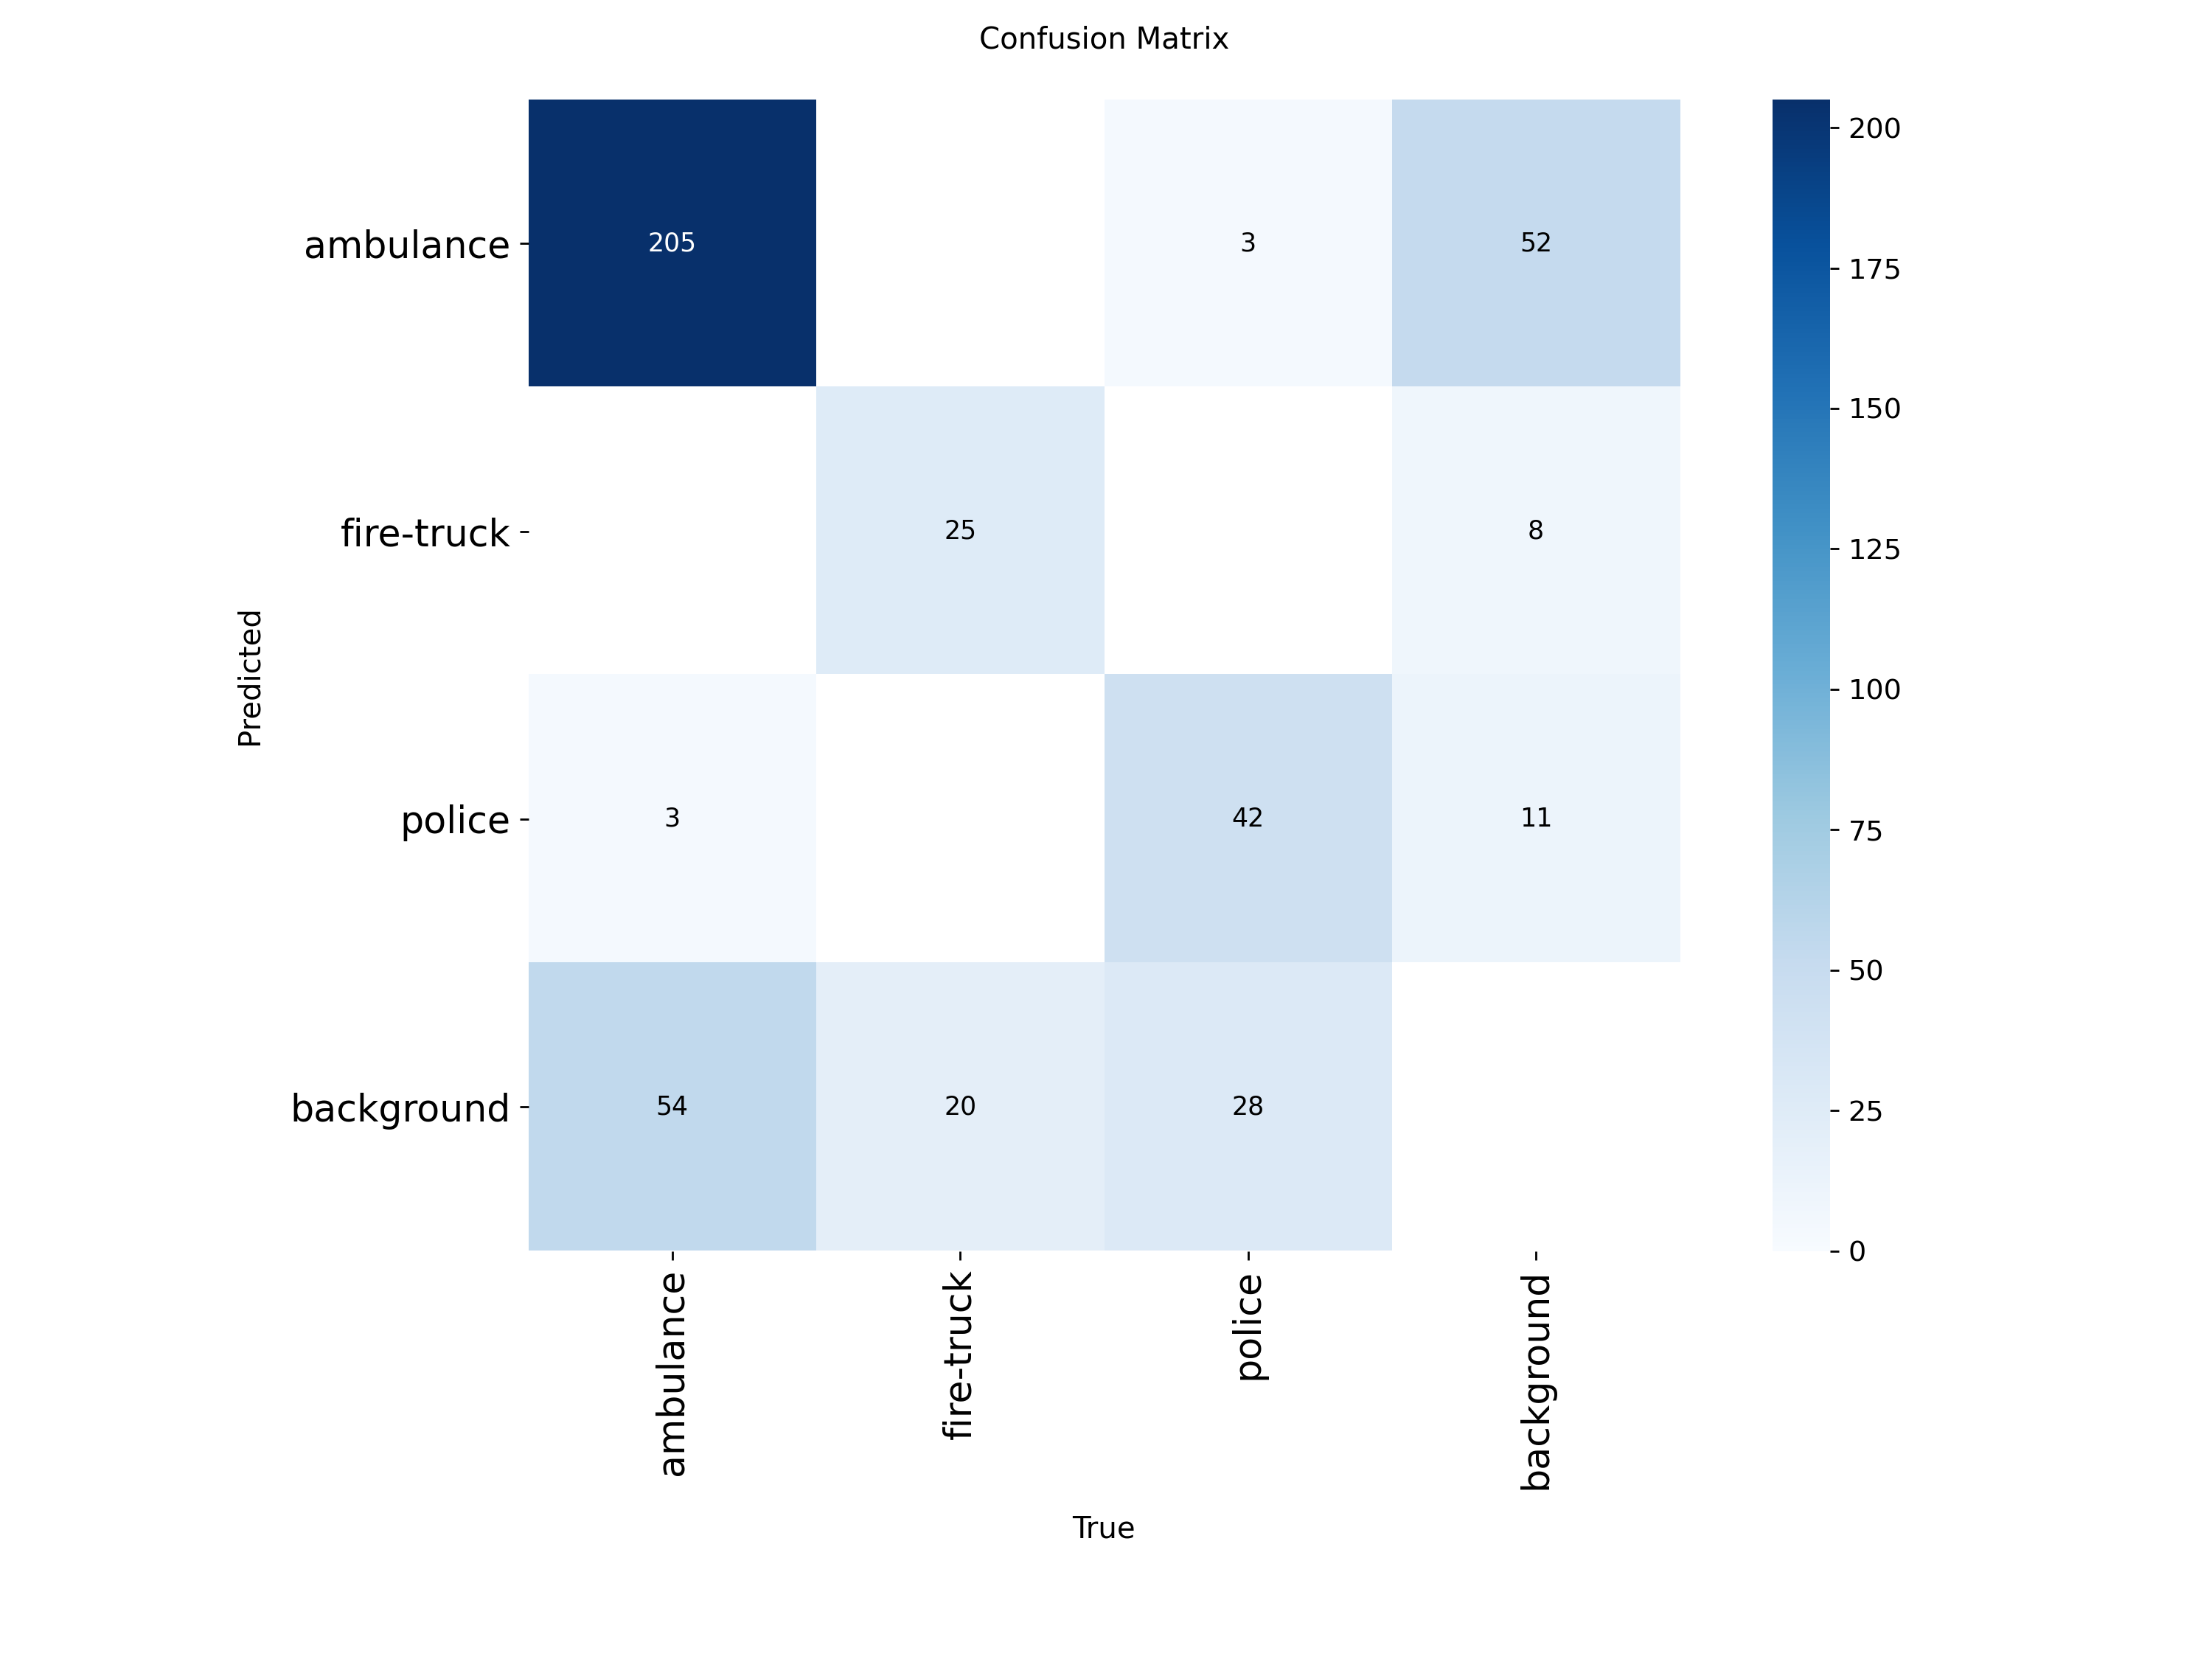

In [7]:
Image("/kaggle/working/runs/detect/train/confusion_matrix.png", width=600)

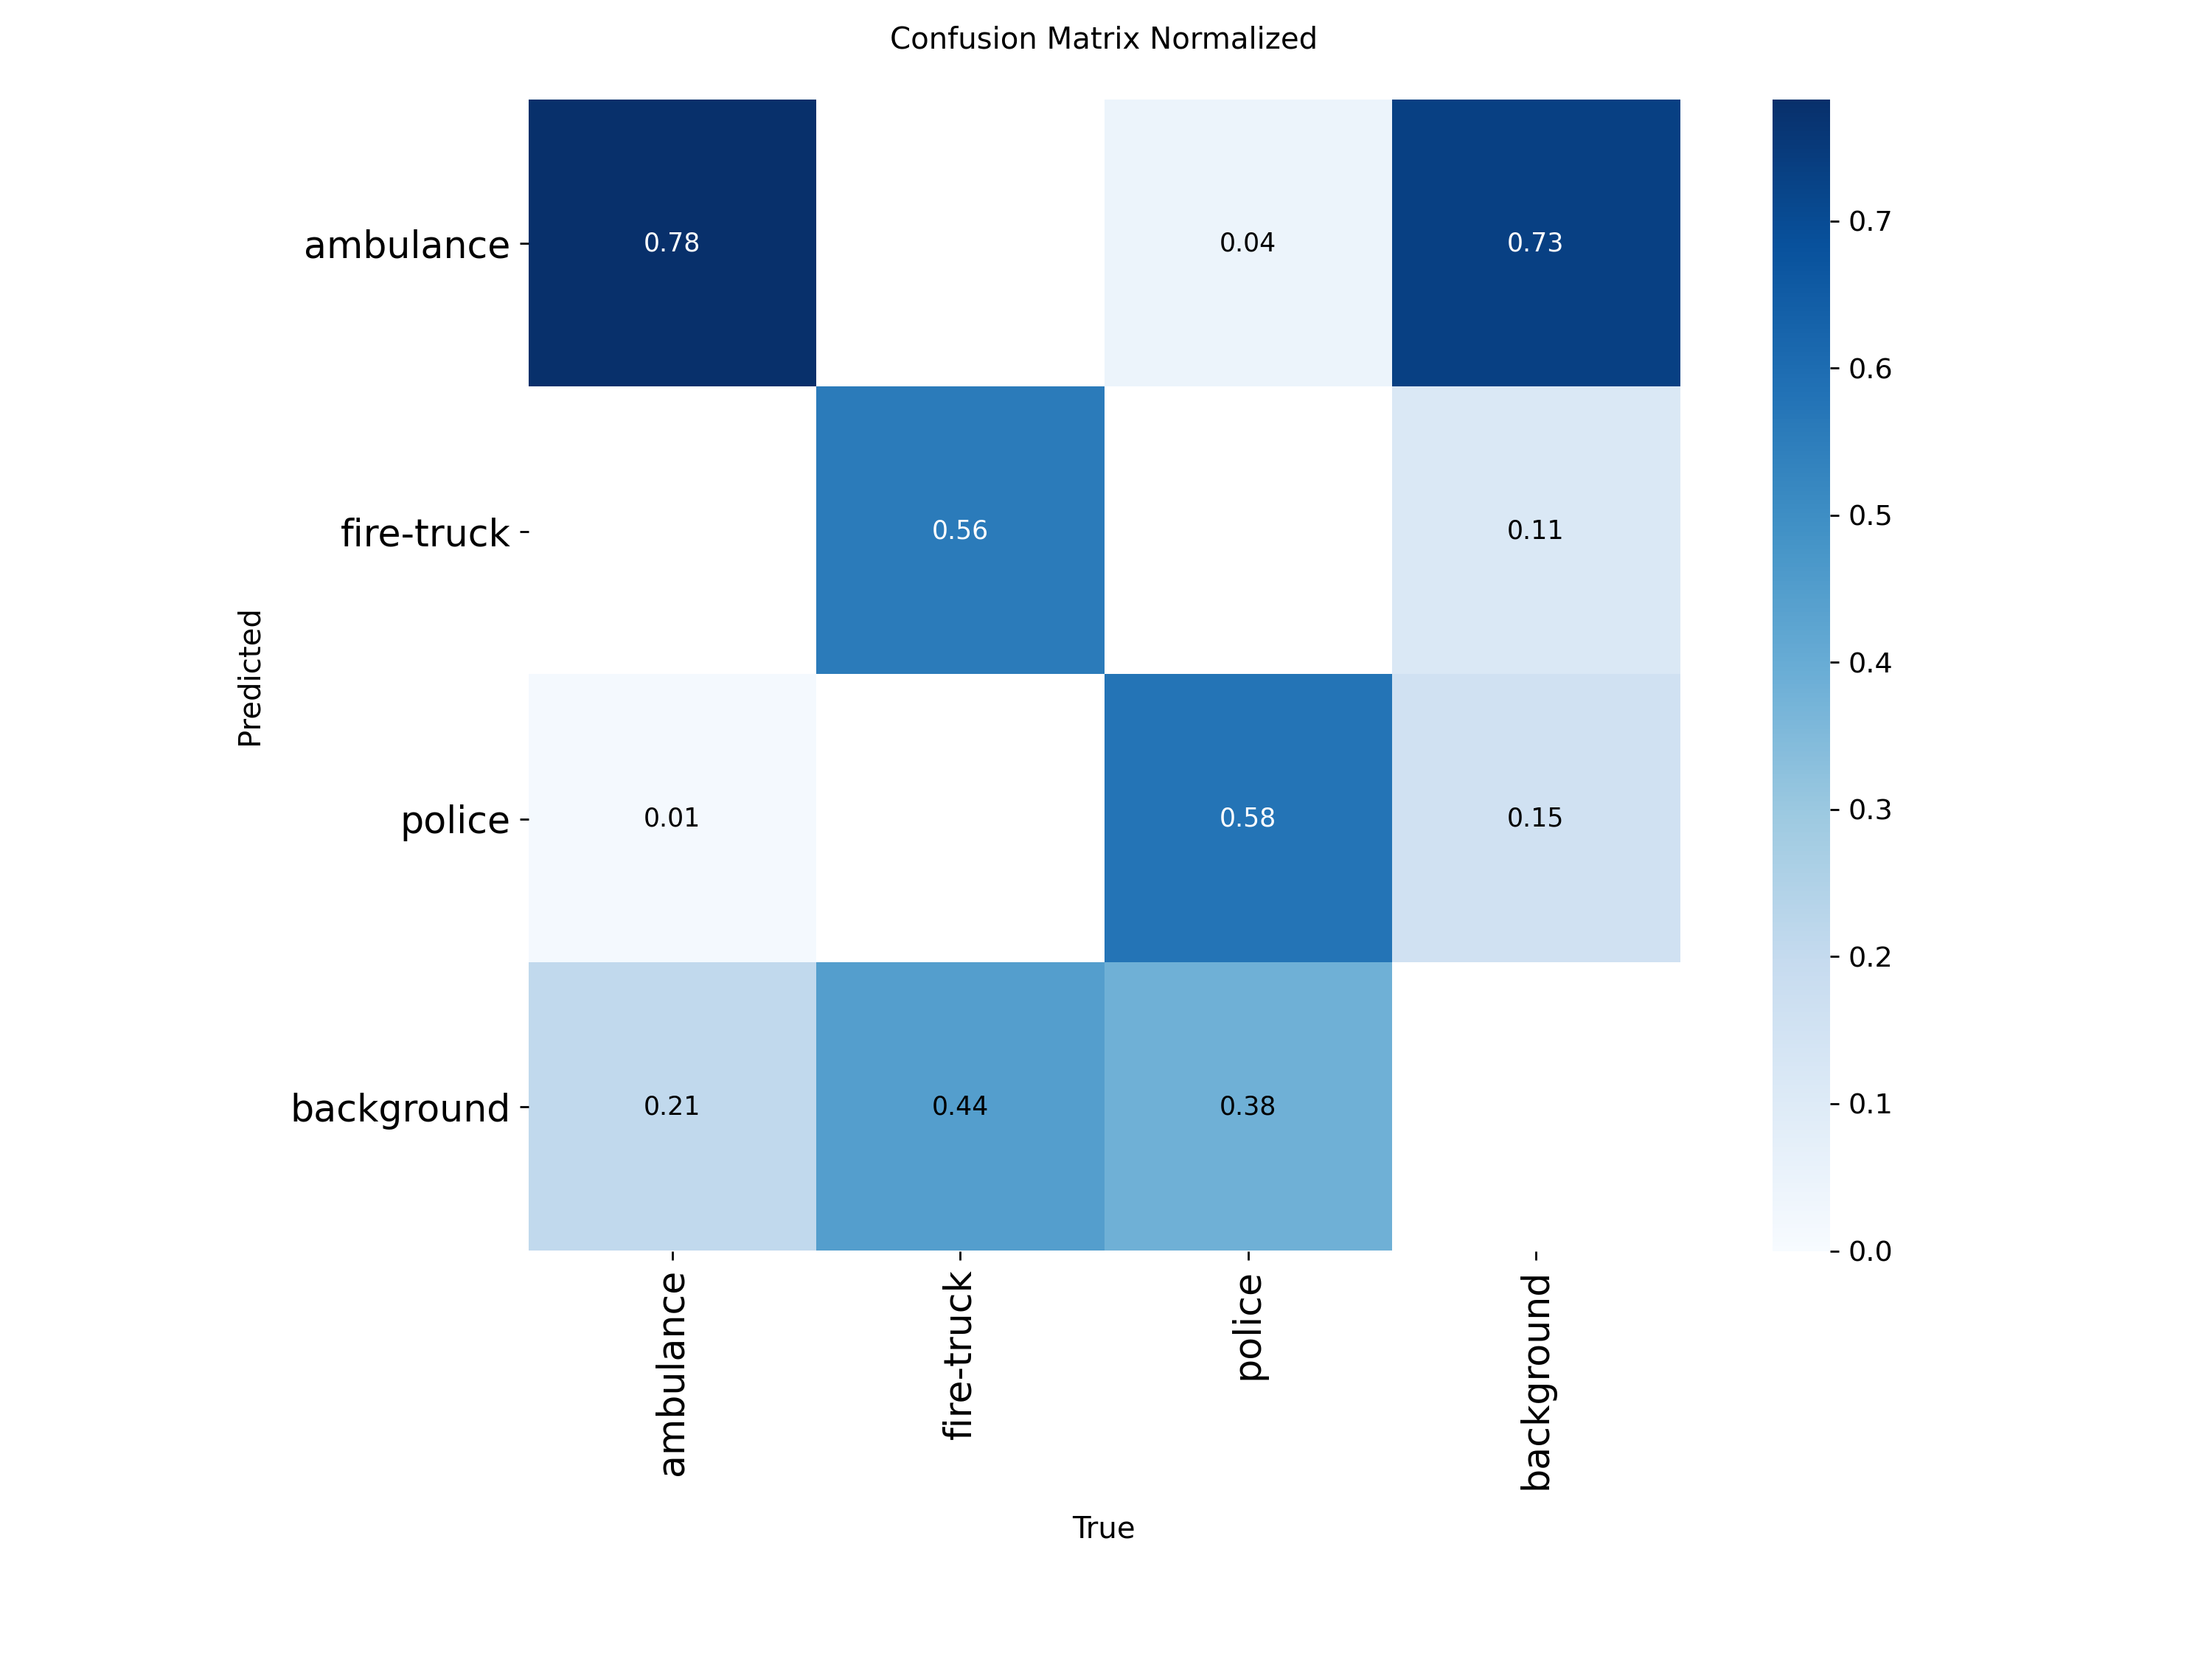

In [8]:
Image("/kaggle/working/runs/detect/train/confusion_matrix_normalized.png", width=600)

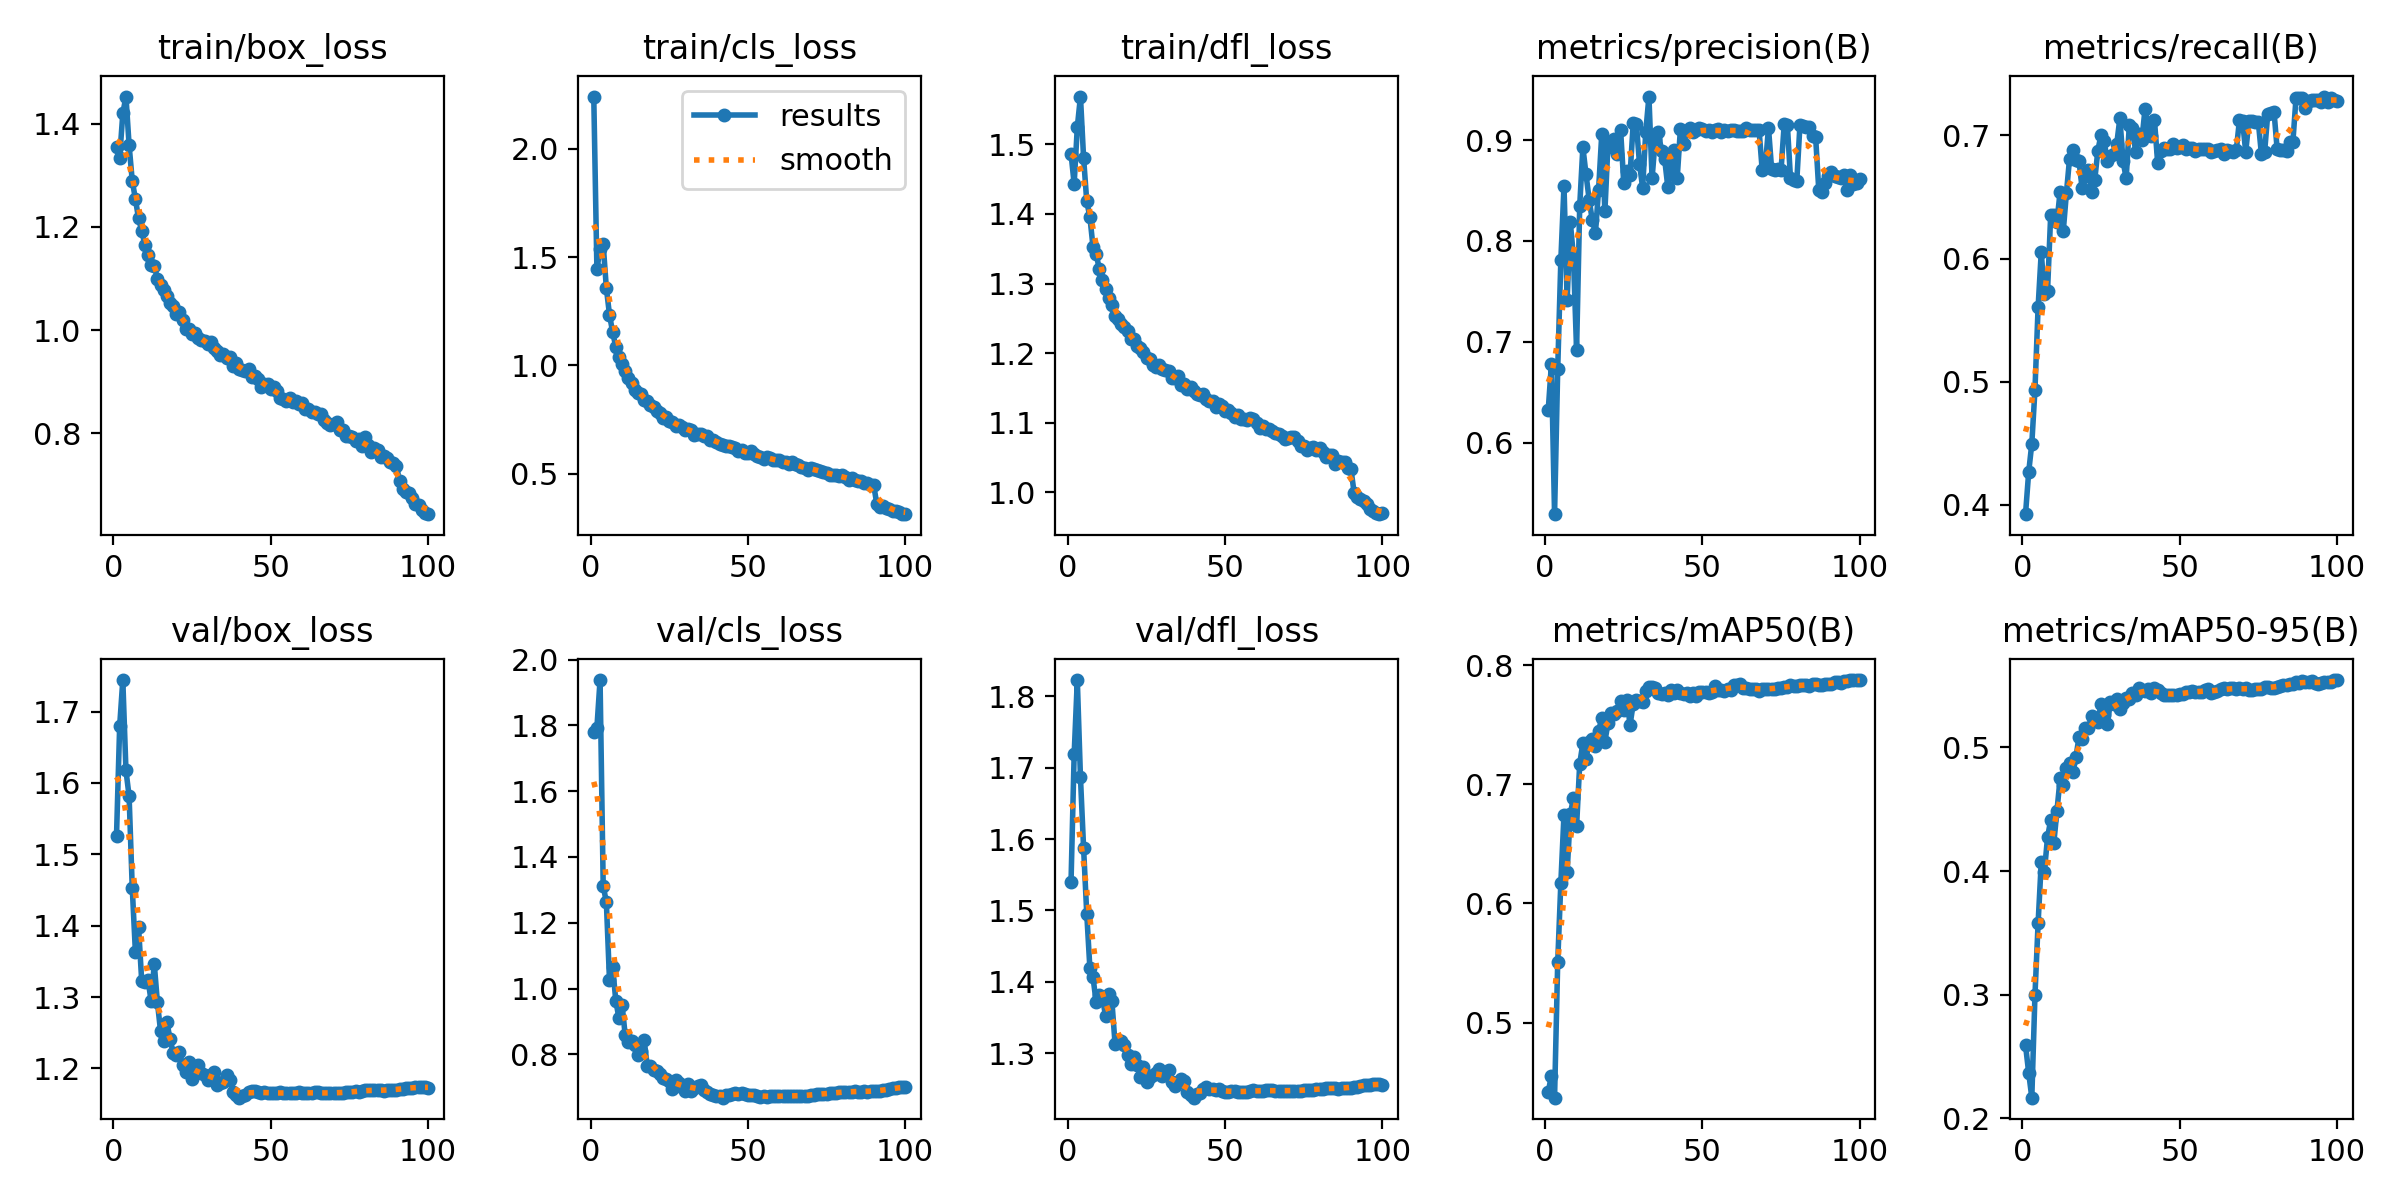

In [9]:
Image("/kaggle/working/runs/detect/train/results.png", width=600)

In [10]:
from ultralytics import YOLO
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from IPython.display import display
import yaml
from PIL import Image
import shutil

# Function to draw bounding boxes from label file
def draw_ground_truth(img_path, label_path, class_names):
    image = cv2.imread(img_path)
    if image is None:
        # Try with PIL if cv2 fails
        pil_img = Image.open(img_path).convert('RGB')
        image = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    
    h, w, _ = image.shape
    
    if not os.path.exists(label_path):
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Return original if no label
    
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            
            cls, x_center, y_center, box_w, box_h = map(float, parts)
            
            # Convert normalized coordinates to pixel values
            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)
            
            # Draw rectangle and class name
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            class_name = class_names[int(cls)]
            cv2.putText(image, class_name, (x1, y1 - 5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Function to load class names from data.yaml
def load_class_names(yaml_path):
    """Load class names from data.yaml file"""
    try:
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
        class_names = data.get('names', [])
        print(f"✅ Loaded {len(class_names)} classes: {class_names}")
        return class_names
    except Exception as e:
        print(f"❌ Error loading yaml file: {e}")
        return []

# IMPROVED: Convert and VALIDATE images
def create_compatible_images(source_dir, output_dir):
    """Convert all images using OpenCV for better YOLO compatibility"""
    os.makedirs(output_dir, exist_ok=True)
    converted = []
    failed = []
    
    print(f"Converting images from {source_dir}...")
    image_files = [f for f in os.listdir(source_dir) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
    
    for idx, img_file in enumerate(image_files):
        source_path = os.path.join(source_dir, img_file)
        output_path = os.path.join(output_dir, img_file.rsplit('.', 1)[0] + '.jpg')
        
        try:
            # Method 1: Try OpenCV first (most compatible with YOLO)
            img = cv2.imread(source_path)
            
            if img is None:
                # Method 2: Fallback to PIL if OpenCV fails
                pil_img = Image.open(source_path).convert('RGB')
                img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
            
            # Ensure image is valid
            if img is None or img.size == 0:
                raise ValueError("Image is empty or invalid")
            
            # Save with OpenCV (most compatible with YOLO/OpenCV)
            success = cv2.imwrite(output_path, img, [cv2.IMWRITE_JPEG_QUALITY, 95])
            
            if not success:
                raise ValueError("cv2.imwrite failed")
            
            # CRITICAL: Validate the saved image can be read back
            test_img = cv2.imread(output_path)
            if test_img is None:
                raise ValueError("Saved image cannot be read back")
            
            converted.append(output_path)
            
            if (idx + 1) % 100 == 0:
                print(f"  ✓ Converted & validated {idx + 1}/{len(image_files)} images...")
                
        except Exception as e:
            failed.append((img_file, str(e)[:100]))
            if len(failed) <= 5:  # Show first 5 errors
                print(f"  ❌ Failed: {img_file} - {str(e)[:80]}")
    
    print(f"\n✅ Successfully converted: {len(converted)}/{len(image_files)} images")
    if failed:
        print(f"❌ Failed to convert: {len(failed)} images")
        if len(failed) > 5:
            print(f"   (showing first 5, {len(failed)-5} more failed)")
    
    return converted, failed

# Load class names from data.yaml
yaml_path = "/kaggle/working/PCB-2/data.yaml"
class_names = load_class_names(yaml_path)

# Create a temporary directory for converted images
temp_image_dir = "/kaggle/working/temp_valid_images"
source_image_dir = "/kaggle/working/PCB-2/valid/images"

print("\n" + "="*60)
print("STEP 1: Converting images to compatible format")
print("="*60)

# Convert images to ensure compatibility
converted_images, failed_conversions = create_compatible_images(source_image_dir, temp_image_dir)

if not converted_images:
    print("❌ No images could be converted. Please check the source directory.")
    print(f"Source directory exists: {os.path.exists(source_image_dir)}")
    print(f"Files in source: {len(os.listdir(source_image_dir)) if os.path.exists(source_image_dir) else 0}")
    exit()

# Quick validation: test if YOLO can read a sample image
print("\n" + "="*60)
print("VALIDATION: Testing if YOLO can read converted images")
print("="*60)

test_img_path = converted_images[0]
try:
    test_read = cv2.imread(test_img_path)
    if test_read is not None:
        print(f"✅ OpenCV can read converted images (tested: {os.path.basename(test_img_path)})")
        print(f"   Image shape: {test_read.shape}")
    else:
        print(f"❌ WARNING: OpenCV cannot read converted image: {test_img_path}")
except Exception as e:
    print(f"❌ ERROR during validation: {e}")

# Load YOLO model
print("\n" + "="*60)
print("STEP 2: Loading YOLO model")
print("="*60)
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# Run predictions on converted images
print("\n" + "="*60)
print("STEP 3: Running predictions")
print("="*60)
print(f"Predicting on {len(converted_images)} images...\n")

try:
    # Try batch prediction first
    results = model.predict(source=temp_image_dir, conf=0.25, save=True, project='/kaggle/working/runs/detect', name='predict', exist_ok=True)
    print(f"✅ Batch prediction successful! Processed {len(results)} images")
    successful_count = len(results)
except Exception as e:
    print(f"⚠️ Batch prediction failed: {str(e)[:200]}")
    print("\nTrying individual predictions with error tracking...\n")
    
    # Fallback to individual predictions with better error handling
    results = []
    successful_count = 0
    sample_errors = []
    
    for idx, img_path in enumerate(converted_images[:10]):  # Test first 10
        try:
            # Verify image before prediction
            test_img = cv2.imread(img_path)
            if test_img is None:
                raise ValueError(f"Cannot read image with cv2: {img_path}")
            
            result = model.predict(source=img_path, conf=0.25, save=True, verbose=False)
            results.extend(result)
            successful_count += 1
            
        except Exception as img_error:
            error_msg = str(img_error)[:100]
            sample_errors.append((os.path.basename(img_path), error_msg))
            if len(sample_errors) <= 3:
                print(f"  ❌ Failed: {os.path.basename(img_path)}")
                print(f"     Error: {error_msg}")
    
    print(f"\n✅ Successfully predicted: {successful_count}/10 test images")
    
    if successful_count == 0:
        print("\n❌ CRITICAL: No predictions succeeded. Diagnostic info:")
        print(f"   - Converted images exist: {len(converted_images)}")
        print(f"   - Sample converted path: {converted_images[0]}")
        print(f"   - File exists: {os.path.exists(converted_images[0])}")
        print(f"   - File size: {os.path.getsize(converted_images[0])} bytes")
        print(f"\nSample errors:")
        for fname, err in sample_errors[:3]:
            print(f"   {fname}: {err}")
        exit()

if successful_count == 0:
    print("❌ No successful predictions. Cannot continue.")
    exit()

# Get prediction folder
print("\n" + "="*60)
print("STEP 4: Displaying results")
print("="*60)

predict_folders = glob.glob('/kaggle/working/runs/detect/predict*/')
if not predict_folders:
    print("❌ No prediction folders found!")
    exit()

latest_folder = max(predict_folders, key=os.path.getmtime)
predicted_imgs = sorted(glob.glob(f'{latest_folder}/*.jpg'))
print(f"Found {len(predicted_imgs)} prediction images in {latest_folder}\n")

# Paths
label_dir = '/kaggle/working/PCB-2/valid/labels'

# Create mappings
pred_img_dict = {os.path.basename(p): p for p in predicted_imgs}
temp_to_original = {os.path.basename(f): f.replace(temp_image_dir, source_image_dir) 
                    for f in converted_images}

# Display first 10 images
print("Displaying first 10 comparisons...\n")
display_count = 0

for pred_filename in sorted(pred_img_dict.keys()):
    if display_count >= 10:
        break
    
    # Get paths
    pred_path = pred_img_dict[pred_filename]
    orig_filename = pred_filename.rsplit('.', 1)[0] + '.jpg'  # Handle extension changes
    orig_path = temp_to_original.get(pred_filename, os.path.join(source_image_dir, orig_filename))
    label_path = os.path.join(label_dir, pred_filename.rsplit('.', 1)[0] + '.txt')
    
    try:
        # Load and annotate ground truth
        orig_annotated = draw_ground_truth(orig_path, label_path, class_names)
        
        # Load prediction image
        pred_img = mpimg.imread(pred_path)
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        
        axes[0].imshow(orig_annotated)
        axes[0].set_title(f"Ground Truth\n{pred_filename}", fontsize=9)
        axes[0].axis('off')
        
        axes[1].imshow(pred_img)
        axes[1].set_title(f"Model Prediction\n{pred_filename}", fontsize=9)
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        display_count += 1
        print(f"✅ Displayed {display_count}/10")
        
    except Exception as e:
        print(f"❌ Error displaying {pred_filename}: {str(e)[:80]}")
        continue

print("\n" + "="*60)
print("COMPLETE!")
print("="*60)
print(f"✅ Displayed {display_count} image comparisons")
print(f"📁 All predictions saved to: {latest_folder}")
print(f"🗑️ Temporary images in: {temp_image_dir}")
print(f"\n💡 TIP: If successful, run predictions on all images:")
print(f"   results = model.predict(source='{temp_image_dir}', conf=0.25, save=True)")

❌ Error loading yaml file: [Errno 2] No such file or directory: '/kaggle/working/PCB-2/data.yaml'

STEP 1: Converting images to compatible format
Converting images from /kaggle/working/PCB-2/valid/images...


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/PCB-2/valid/images'

In [ ]:
import shutil
import os

def create_zip_backup(source_folder, zip_name='runs_backup'):
    """Create zip file with size information"""
    
    # Check if source exists
    if not os.path.exists(source_folder):
        print(f"❌ Folder not found: {source_folder}")
        return None
    
    # Get folder size before zipping
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(source_folder):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.exists(fp):
                total_size += os.path.getsize(fp)
    
    print(f"📁 Original folder size: {total_size / (1024*1024):.2f} MB")
    print(f"🗜️  Creating zip file...")
    
    # Create zip
    zip_path = f'/kaggle/working/{zip_name}'
    shutil.make_archive(zip_path, 'zip', source_folder)
    
    # Show results
    zip_file = f'{zip_path}.zip'
    zip_size = os.path.getsize(zip_file)
    compression_ratio = (1 - zip_size/total_size) * 100
    
    print(f"✅ Zip created: {zip_file}")
    print(f"📦 Zip size: {zip_size / (1024*1024):.2f} MB")
    print(f"💾 Compression: {compression_ratio:.1f}%")
    
    return zip_file

# Create the zip
zip_file = create_zip_backup('/kaggle/working/runs', 'runs_backup')

# Show download link
if zip_file:
    from IPython.display import FileLink
    print("\n📥 Click below to download:")
    display(FileLink(zip_file))

In [ ]:
import shutil
import os

def create_zip_backup(source_folder, zip_name='temp_valid_imagesbackup'):
    """Create zip file with size information"""
    
    # Check if source exists
    if not os.path.exists(source_folder):
        print(f"❌ Folder not found: {source_folder}")
        return None
    
    # Get folder size before zipping
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(source_folder):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.exists(fp):
                total_size += os.path.getsize(fp)
    
    print(f"📁 Original folder size: {total_size / (1024*1024):.2f} MB")
    print(f"🗜️  Creating zip file...")
    
    # Create zip
    zip_path = f'/kaggle/working/{zip_name}'
    shutil.make_archive(zip_path, 'zip', source_folder)
    
    # Show results
    zip_file = f'{zip_path}.zip'
    zip_size = os.path.getsize(zip_file)
    compression_ratio = (1 - zip_size/total_size) * 100
    
    print(f"✅ Zip created: {zip_file}")
    print(f"📦 Zip size: {zip_size / (1024*1024):.2f} MB")
    print(f"💾 Compression: {compression_ratio:.1f}%")
    
    return zip_file

# Create the zip
zip_file = create_zip_backup('/kaggle/working/temp_valid_images', 'temp_valid_imagesbackup')

# Show download link
if zip_file:
    from IPython.display import FileLink
    print("\n📥 Click below to download:")
    display(FileLink(zip_file))